<a href="https://colab.research.google.com/github/thisisgsn-cpu/northstar-analytics-project/blob/main/notebooks/02_r_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
install.packages("dplyr")
install.packages("ggplot2")
install.packages("stringr")
install.packages("scales")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [3]:
library(dplyr)
library(ggplot2)
library(stringr)
library(scales)

cat("All analytical libraries loaded successfully")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




All analytical libraries loaded successfully

In [4]:
system("git clone https://github.com/thisisgsn-cpu/northstar-analytics-project.git")

In [5]:
orders <- read.csv("/content/northstar-analytics-project/data/orders.csv")
deliveries <- read.csv("/content/northstar-analytics-project/data/deliveries.csv")
customers <- read.csv("/content/northstar-analytics-project/data/customers.csv")
drivers <- read.csv("/content/northstar-analytics-project/data/drivers.csv")
vehicles <- read.csv("/content/northstar-analytics-project/data/vehicles.csv")
complaints <- read.csv("/content/northstar-analytics-project/data/complaints.csv")
app_events <- read.csv("/content/northstar-analytics-project/data/app_events.csv")

cat("All datasets loaded successfully")

All datasets loaded successfully

In [ ]:
str(orders)

str(deliveries)

str(customers)

'data.frame':	1250 obs. of  11 variables:
 $ order_id             : chr  "O00001" "O00002" "O00003" "O00004" ...
 $ customer_id          : chr  "C0292" "C0459" "C0161" "C0520" ...
 $ service_type         : chr  "Passenger" "Passenger" "Passenger" "Parcel" ...
 $ order_created_at     : chr  "2024-08-20 14:43:00" "2024-05-14 22:16:00" "2025-09-02 14:37:00" "2025-01-11 17:15:00" ...
 $ promised_window_hours: int  6 24 4 2 12 1 2 4 12 6 ...
 $ pickup_zone          : chr  "Airport" "North" "West" "RiverSide" ...
 $ dropoff_zone         : chr  "South" "AIRPORT" "AIRPORT" "North" ...
 $ priority_level       : chr  "Medium" "Low" "High" "Medium" ...
 $ order_value          : num  126.7 109.3 33.5 10 125.6 ...
 $ booking_channel      : chr  "App" "App" "Phone" "App" ...
 $ special_handling_flag: int  0 0 0 1 0 1 0 0 0 0 ...
'data.frame':	950 obs. of  13 variables:
 $ delivery_id                  : chr  "DL00001" "DL00002" "DL00003" "DL00004" ...
 $ order_id                     : chr  "O00938" "

In [ ]:
head(orders)

head(deliveries)

head(customers)

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<int>
1,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
2,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
3,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
4,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
5,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0
6,O00006,C0437,Retail,2024-08-05 04:55:00,1,CENTRAL,East,High,151.44,Web,1


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>
1,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
2,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
3,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51
4,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62
5,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22
6,DL00006,O00029,D037,V098,H03,2024-09-11 12:40:00,2024-09-12 17:11:52.384869,Delayed,13.84,0,0,1.57,9.58


,customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>
1,C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
2,C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
3,C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,,Active
4,C0004,75,CENTRAL,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
5,C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active
6,C0006,41,WEST,Consumer,2024-03-29 13:26:00,39.9,43.3,Web,Active


In [ ]:
orders$pickup_zone <- toupper(orders$pickup_zone)

orders$dropoff_zone <- toupper(orders$dropoff_zone)

customers$preferred_channel[
    customers$preferred_channel == ""
] <- "UNKNOWN"

deliveries$delivery_status <- toupper(deliveries$delivery_status)

cat("Operational data cleaning completed successfully")

Operational data cleaning completed successfully

In [ ]:
sum(is.na(orders))

sum(is.na(deliveries))

sum(is.na(customers))

sum(is.na(complaints))

[1] 0

[1] 14

[1] 20

[1] 16

In [ ]:
delivery_status_analysis <- deliveries %>%

group_by(delivery_status) %>%

summarise(

    total_deliveries = n(),

    average_route_distance = mean(
        route_distance_km,
        na.rm = TRUE
    ),

    average_operational_cost = mean(
        fuel_or_charge_cost,
        na.rm = TRUE
    ),

    average_customer_rating = mean(
        customer_rating_post_delivery,
        na.rm = TRUE
    )

)

delivery_status_analysis

delivery_status,total_deliveries,average_route_distance,average_operational_cost,average_customer_rating
<chr>,<int>,<dbl>,<dbl>,<dbl>
DELAYED,202,14.67025,13.13871,3.114975
FAILED,132,13.36530,13.14795,3.049313
ONTIME,616,13.77636,12.67805,4.283273


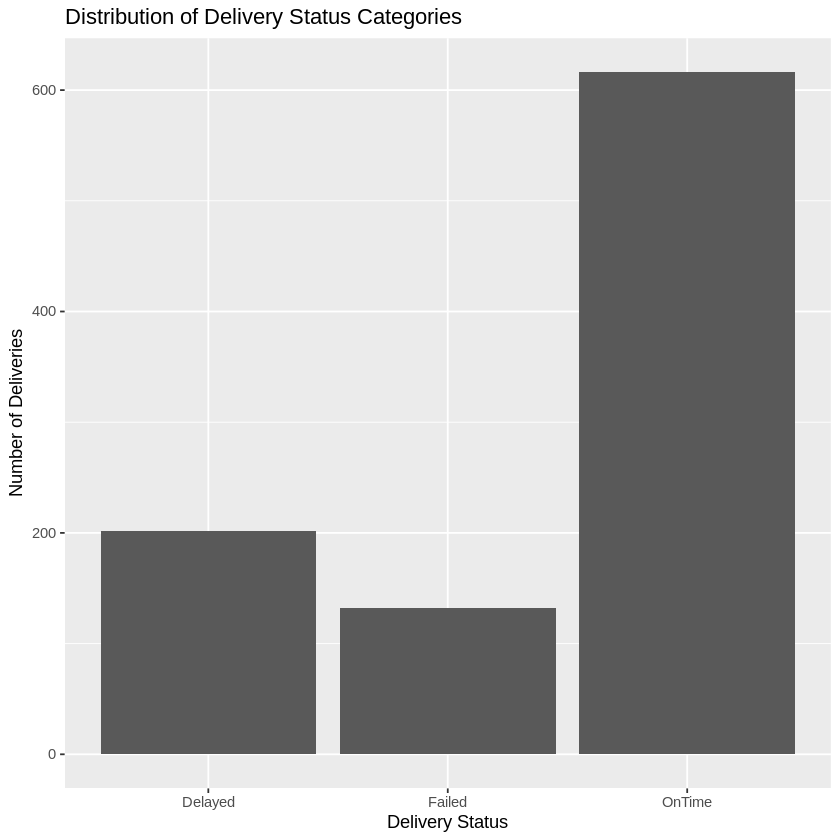

In [5]:
ggplot(
    deliveries,
    aes(x = delivery_status)
) +

geom_bar() +

labs(
    title = "Distribution of Delivery Status Categories",
    x = "Delivery Status",
    y = "Number of Deliveries"
)

In [6]:
customer_satisfaction_analysis <- deliveries %>%

group_by(delivery_status) %>%

summarise(

    average_customer_rating = mean(
        customer_rating_post_delivery,
        na.rm = TRUE
    ),

    minimum_customer_rating = min(
        customer_rating_post_delivery,
        na.rm = TRUE
    ),

    maximum_customer_rating = max(
        customer_rating_post_delivery,
        na.rm = TRUE
    ),

    total_delivery_records = n()

)

customer_satisfaction_analysis

delivery_status,average_customer_rating,minimum_customer_rating,maximum_customer_rating,total_delivery_records
<chr>,<dbl>,<dbl>,<dbl>,<int>
Delayed,3.114975,1.00,5,202
Failed,3.049313,1.00,5,132
OnTime,4.283273,1.99,5,616


Warning message:
“Removed 14 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


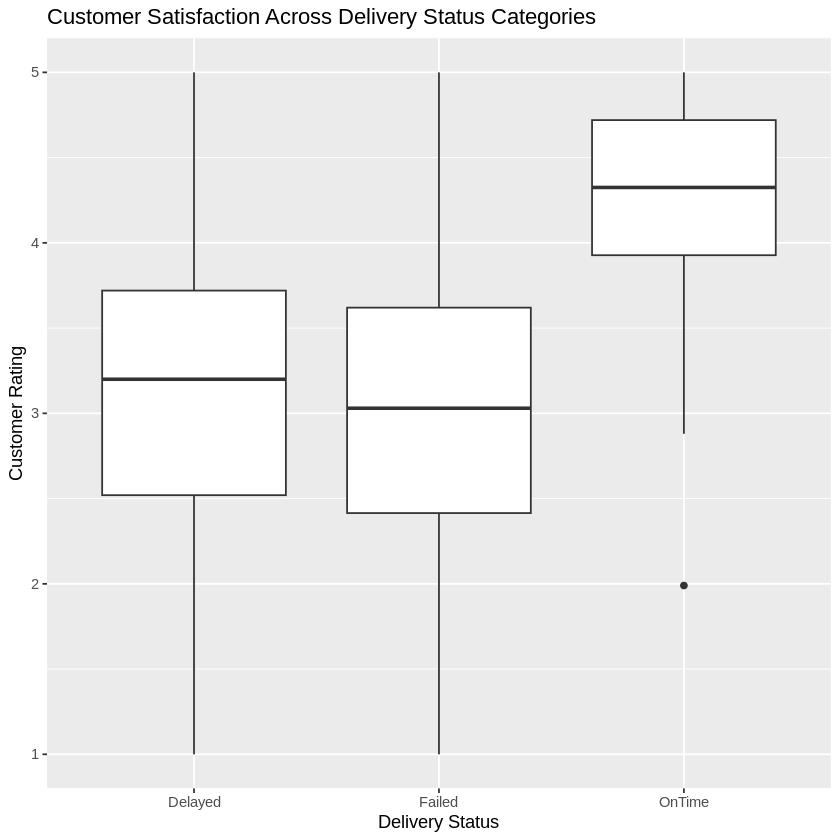

In [7]:
ggplot(
    deliveries,
    aes(
        x = delivery_status,
        y = customer_rating_post_delivery
    )
) +

geom_boxplot() +

labs(
    title = "Customer Satisfaction Across Delivery Status Categories",
    x = "Delivery Status",
    y = "Customer Rating"
)

In [6]:
driver_override_analysis <- deliveries %>%

left_join(
    drivers,
    by = "driver_id"
) %>%

group_by(base_zone) %>%

summarise(

    average_route_overrides = mean(
        manual_route_override_count,
        na.rm = TRUE
    ),

    average_customer_rating = mean(
        customer_rating_post_delivery,
        na.rm = TRUE
    ),

    total_deliveries = n()

)

driver_override_analysis

base_zone,average_route_overrides,average_customer_rating,total_deliveries
<chr>,<dbl>,<dbl>,<int>
AIRPORT,0.9824561,3.990926,57
Airport,0.8909091,3.796182,55
CENTRAL,0.9384615,3.862615,65
Central,0.9411765,3.732985,68
Ctr,1.0666667,4.002414,30
EAST,0.7777778,3.868333,36
East,0.9253731,3.913284,67
NORTH,1.0000000,4.101447,76
North,1.0895522,3.558806,67


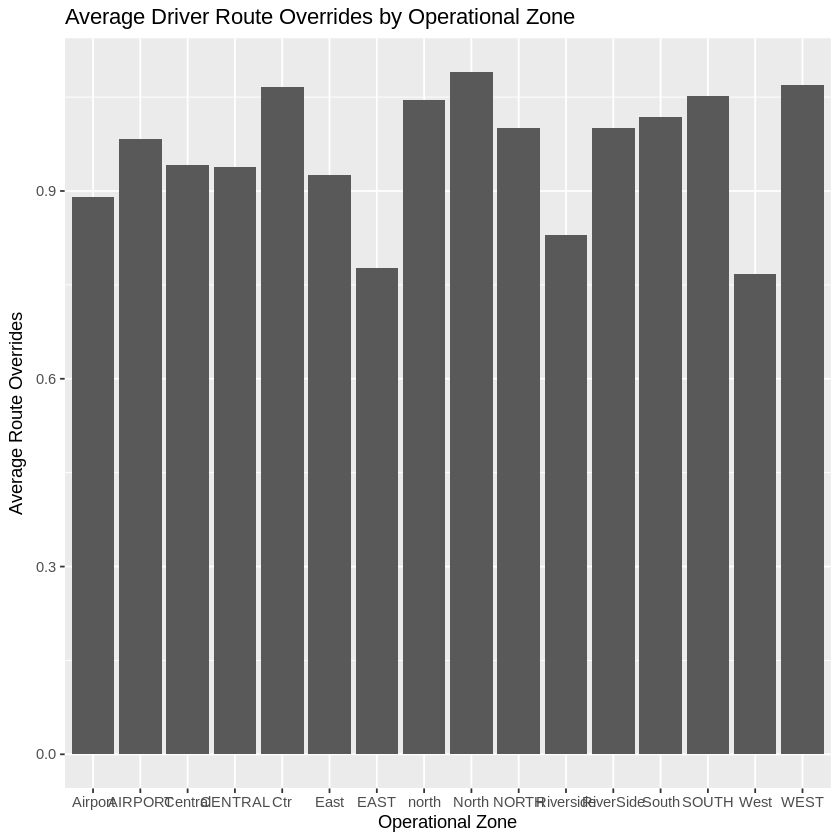

In [7]:
ggplot(
    driver_override_analysis,
    aes(
        x = base_zone,
        y = average_route_overrides
    )
) +

geom_bar(
    stat = "identity"
) +

labs(
    title = "Average Driver Route Overrides by Operational Zone",
    x = "Operational Zone",
    y = "Average Route Overrides"
)

In [8]:
complaints$created_at <- as.Date(
    complaints$created_at
)

complaints$month <- format(
    complaints$created_at,
    "%Y-%m"
)

complaint_trend_analysis <- complaints %>%

group_by(
    month,
    severity
) %>%

summarise(
    total_complaints = n(),
    .groups = "drop"
)

complaint_trend_analysis

month,severity,total_complaints
<chr>,<chr>,<int>
2024-01,High,5
2024-01,Low,3
2024-01,Medium,8
2024-02,High,2
2024-02,Low,3
2024-02,Medium,4
2024-03,High,9
2024-03,Low,5
2024-03,Medium,6


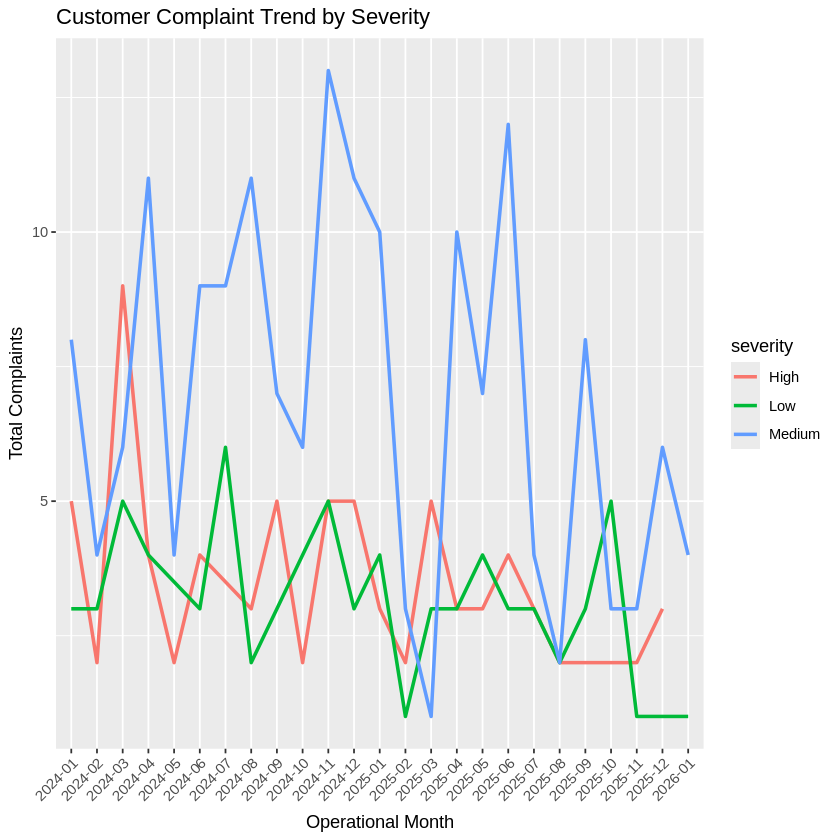

In [10]:
ggplot(
    complaint_trend_analysis,
    aes(
        x = month,
        y = total_complaints,
        color = severity,
        group = severity
    )
) +

geom_line(linewidth = 1) +

labs(
    title = "Customer Complaint Trend by Severity",
    x = "Operational Month",
    y = "Total Complaints"
) +

theme(
    axis.text.x = element_text(
        angle = 45,
        hjust = 1
    )
)

In [11]:
app_performance_analysis <- app_events %>%

group_by(
    device_type,
    event_type
) %>%

summarise(

    average_api_latency = mean(
        api_latency_ms,
        na.rm = TRUE
    ),

    successful_events = sum(
        success_flag == 1,
        na.rm = TRUE
    ),

    failed_events = sum(
        success_flag == 0,
        na.rm = TRUE
    ),

    total_events = n(),

    .groups = "drop"
)

app_performance_analysis

device_type,event_type,average_api_latency,successful_events,failed_events,total_events
<chr>,<chr>,<dbl>,<int>,<int>,<int>
Android,cancel_attempt,438.7143,14,0,14
Android,chat_escalated,532.7500,6,10,16
Android,chat_opened,444.8511,47,0,47
Android,delivery_instruction_update,519.5135,37,0,37
Android,eta_refresh,460.6296,54,0,54
Android,payment_retry,460.7647,23,11,34
Android,search_route,450.4000,50,0,50
Android,track_order,453.7619,63,0,63
Web,cancel_attempt,353.2000,5,0,5


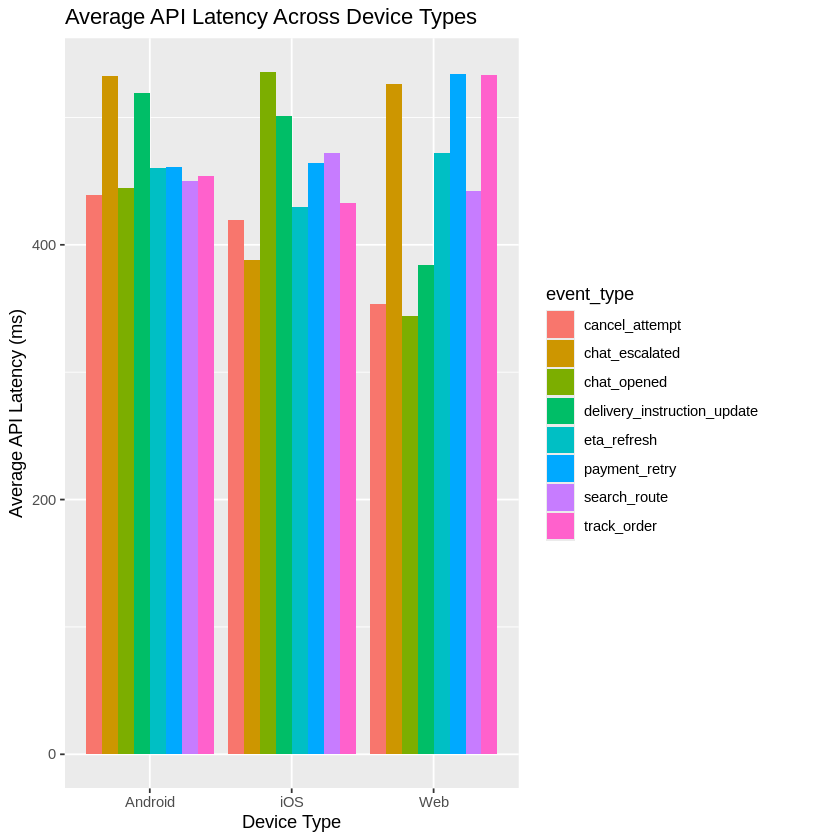

In [12]:
ggplot(
    app_performance_analysis,
    aes(
        x = device_type,
        y = average_api_latency,
        fill = event_type
    )
) +

geom_bar(
    stat = "identity",
    position = "dodge"
) +

labs(
    title = "Average API Latency Across Device Types",
    x = "Device Type",
    y = "Average API Latency (ms)"
)

In [13]:
battery_health_analysis <- deliveries %>%

left_join(
    vehicles,
    by = "vehicle_id"
) %>%

filter(
    !is.na(battery_health_pct),
    !is.na(customer_rating_post_delivery)
) %>%

group_by(maintenance_status) %>%

summarise(

    average_battery_health = mean(
        battery_health_pct,
        na.rm = TRUE
    ),

    average_customer_rating = mean(
        customer_rating_post_delivery,
        na.rm = TRUE
    ),

    total_deliveries = n(),

    .groups = "drop"
)

battery_health_analysis

maintenance_status,average_battery_health,average_customer_rating,total_deliveries
<chr>,<dbl>,<dbl>,<int>
Active,76.69371,3.942240,509
InRepair,76.70760,3.634080,250
Scheduled,78.52434,3.931776,152


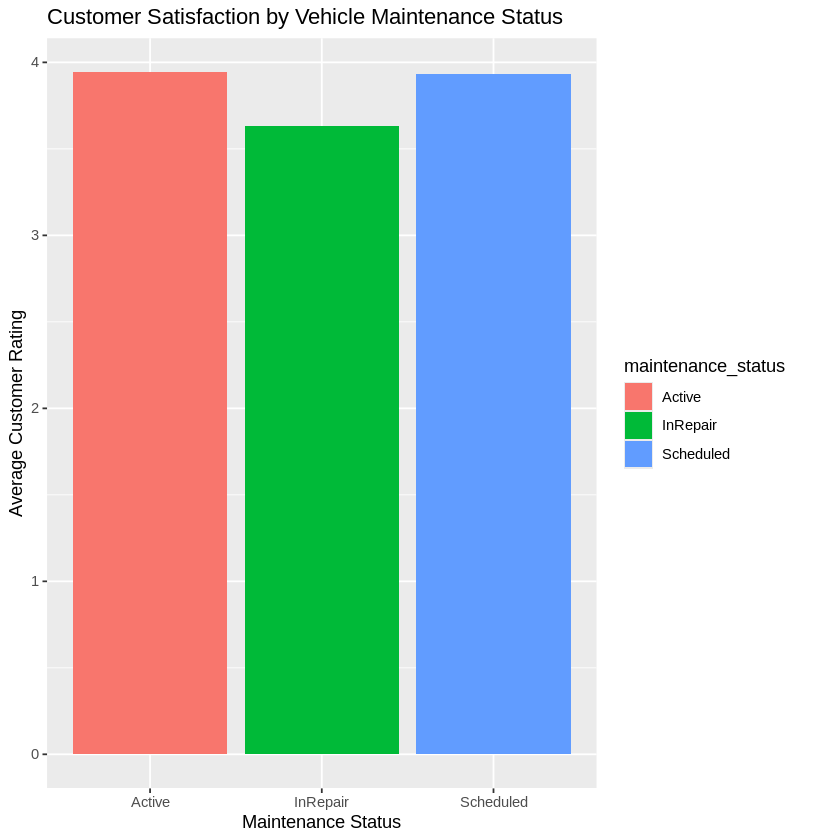

In [14]:
ggplot(
    battery_health_analysis,
    aes(
        x = maintenance_status,
        y = average_customer_rating,
        fill = maintenance_status
    )
) +

geom_bar(
    stat = "identity"
) +

labs(
    title = "Customer Satisfaction by Vehicle Maintenance Status",
    x = "Maintenance Status",
    y = "Average Customer Rating"
)